## Import Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [36]:
import os
print(os.getcwd())


os.listdir("../data")

d:\sql-pizza-sales-project\python


['orders.csv', 'order_details.csv', 'pizzas.csv', 'pizza_types.csv']

In [37]:
import os

print(os.path.exists("../data/pizza_types.csv"))


True


## Load Data

In [38]:
orders = pd.read_csv("../data/orders.csv")

order_details = pd.read_csv("../data/order_details.csv")

pizzas = pd.read_csv("../data/pizzas.csv")

pizza_types = pd.read_csv(
    "../data/pizza_types.csv",
    encoding="cp1252"
)

## Understand Data

In [39]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [40]:
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [41]:
pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [42]:
pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [43]:
print("Orders:", orders.shape)
print("Order Details:", order_details.shape)
print("Pizzas:", pizzas.shape)
print("Pizza Types:", pizza_types.shape)


Orders: (21350, 3)
Order Details: (48620, 4)
Pizzas: (96, 4)
Pizza Types: (32, 4)


In [44]:
print(orders.isnull().sum())
print(order_details.isnull().sum())
print(pizzas.isnull().sum())
print(pizza_types.isnull().sum())


order_id    0
date        0
time        0
dtype: int64
order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64
pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64
pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64


In [45]:
print("Orders duplicates:", orders.duplicated().sum())
print("Order Details duplicates:", order_details.duplicated().sum())
print("Pizzas duplicates:", pizzas.duplicated().sum())
print("Pizza Types duplicates:", pizza_types.duplicated().sum())


Orders duplicates: 0
Order Details duplicates: 0
Pizzas duplicates: 0
Pizza Types duplicates: 0


In [46]:
sales_data = (
    orders
    .merge(order_details, on="order_id", how="inner")
    .merge(pizzas, on="pizza_id", how="inner")
    .merge(pizza_types, on="pizza_type_id", how="inner")
)

In [47]:
sales_data.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [48]:
sales_data.shape

(48620, 12)

In [49]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  int64  
 1   date              48620 non-null  str    
 2   time              48620 non-null  str    
 3   order_details_id  48620 non-null  int64  
 4   pizza_id          48620 non-null  str    
 5   quantity          48620 non-null  int64  
 6   pizza_type_id     48620 non-null  str    
 7   size              48620 non-null  str    
 8   price             48620 non-null  float64
 9   name              48620 non-null  str    
 10  category          48620 non-null  str    
 11  ingredients       48620 non-null  str    
dtypes: float64(1), int64(3), str(8)
memory usage: 4.5 MB


In [50]:
sales_data.duplicated().sum()

np.int64(0)

In [51]:
sales_data.isnull().sum()

order_id            0
date                0
time                0
order_details_id    0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [52]:
# Check whether the keys actually match
# Before merging, you can check unmatched IDs.
missing_pizza_ids = set(order_details["pizza_id"]) - set(pizzas["pizza_id"])

len(missing_pizza_ids)

0

In [53]:
missing_pizza_type_ids = (
    set(pizzas["pizza_type_id"])
    - set(pizza_types["pizza_type_id"])
)

len(missing_pizza_type_ids)

0

In [54]:
missing_order_ids = (
    set(order_details["order_id"])
    - set(orders["order_id"])
)

len(missing_order_ids)

0

In [55]:
# create revenue col

sales_data["revenue"] = (
    sales_data["quantity"] *
    sales_data["price"]
)

In [56]:
sales_data = sales_data.rename(columns={
    "date": "order_date"
})


sales_data["order_date"] = pd.to_datetime(
    sales_data["order_date"]
)

In [57]:
sales_data.columns


Index(['order_id', 'order_date', 'time', 'order_details_id', 'pizza_id',
       'quantity', 'pizza_type_id', 'size', 'price', 'name', 'category',
       'ingredients', 'revenue'],
      dtype='str')

In [58]:
sales_data["year"] = sales_data["order_date"].dt.year

sales_data["month"] = sales_data["order_date"].dt.month

sales_data["month_name"] = sales_data["order_date"].dt.month_name()

sales_data["day_name"] = sales_data["order_date"].dt.day_name()

In [61]:
print(sales_data.columns.tolist())


['order_id', 'order_date', 'time', 'order_details_id', 'pizza_id', 'quantity', 'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients', 'revenue', 'year', 'month', 'month_name', 'day_name']


In [62]:
sales_data["order_hour"] = pd.to_datetime(
    sales_data["time"],
    format="%H:%M:%S"
).dt.hour


In [63]:
sales_data.head()

,order_id,order_date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,revenue,year,month,month_name,day_name,order_hour
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,2015,1,January,Thursday,11
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,2015,1,January,Thursday,11
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,2015,1,January,Thursday,11
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,2015,1,January,Thursday,11
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,2015,1,January,Thursday,11


## Analysis and Visulization

In [64]:
# total revenue
total_revenue = sales_data["revenue"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 817,860.05


In [65]:
# total orders
total_orders = sales_data["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 21,350


In [66]:
# average order value
average_order_value = (
    total_revenue / total_orders
)

print(f"Average Order Value: {average_order_value:,.2f}")

Average Order Value: 38.31


In [70]:
# total pizzas sold
total_pizzas = sales_data["quantity"].sum()

print(f"Total Pizzas Sold: {total_pizzas:,}")

Total Pizzas Sold: 49,574


In [71]:
# create KPI Dictionary
kpis = {
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Total Pizzas Sold": total_pizzas,
    "Average Order Value": average_order_value
}

kpi_df = pd.DataFrame(
    kpis.items(),
    columns=["KPI", "Value"]
)

kpi_df

,KPI,Value
0,Total Revenue,817860.050000
1,Total Orders,21350.000000
2,Total Pizzas Sold,49574.000000
3,Average Order Value,38.307262


In [72]:
# Top 10 Best-Selling Pizzas
top_pizzas = (
    sales_data
    .groupby("name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_pizzas

name
The Classic Deluxe Pizza        2453
The Barbecue Chicken Pizza      2432
The Hawaiian Pizza              2422
The Pepperoni Pizza             2418
The Thai Chicken Pizza          2371
The California Chicken Pizza    2370
The Sicilian Pizza              1938
The Spicy Italian Pizza         1924
The Southwest Chicken Pizza     1917
The Big Meat Pizza              1914
Name: quantity, dtype: int64

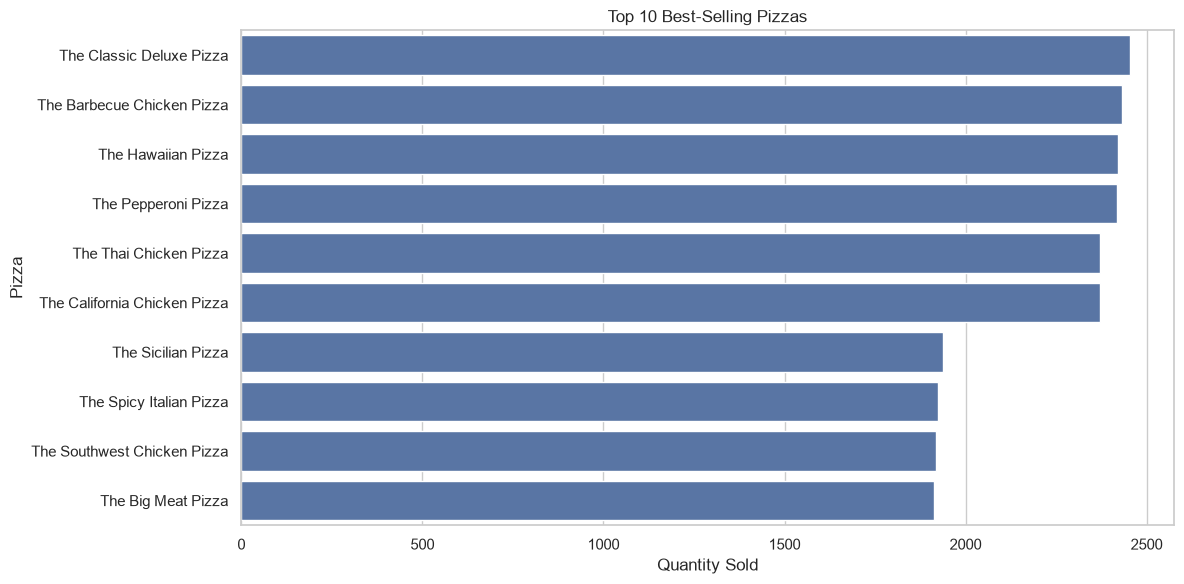

In [73]:
# Plot Top 10 Pizzas
# Using Seaborn:

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_pizzas.values,
    y=top_pizzas.index
)

plt.title("Top 10 Best-Selling Pizzas")
plt.xlabel("Quantity Sold")
plt.ylabel("Pizza")

plt.tight_layout()
plt.show()

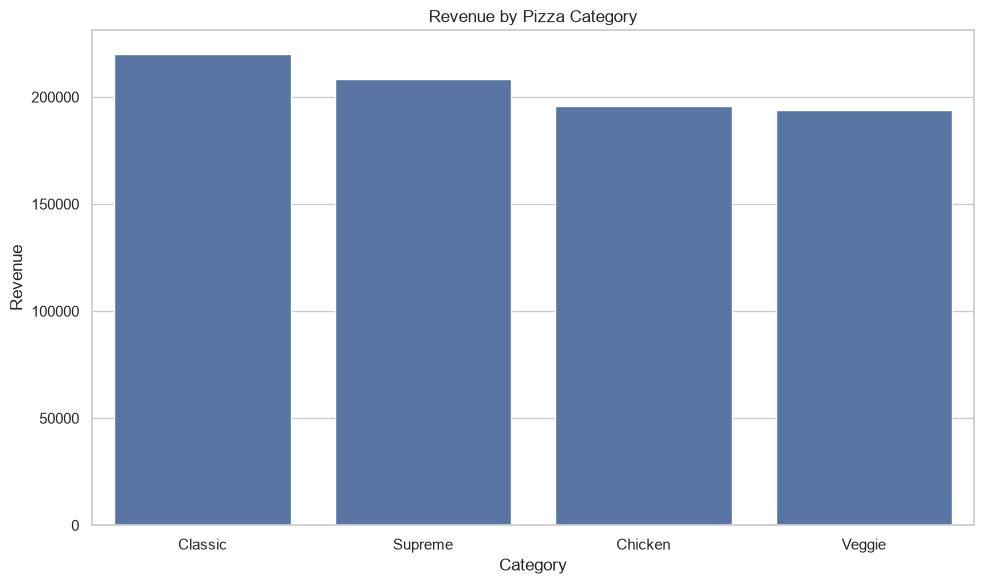

In [76]:
# Revenue by Pizza Category
category_revenue = (
    sales_data
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)


# category_revenue
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Pizza Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

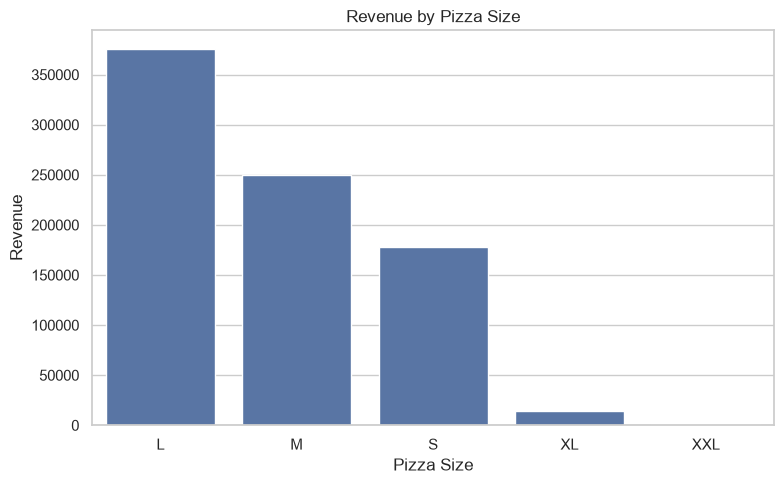

In [77]:
# Revenue by Pizza Size
size_revenue = (
    sales_data
    .groupby("size")["revenue"]
    .sum()
    .sort_values(ascending=False)
)



plt.figure(figsize=(8, 5))

sns.barplot(
    x=size_revenue.index,
    y=size_revenue.values
)

plt.title("Revenue by Pizza Size")
plt.xlabel("Pizza Size")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

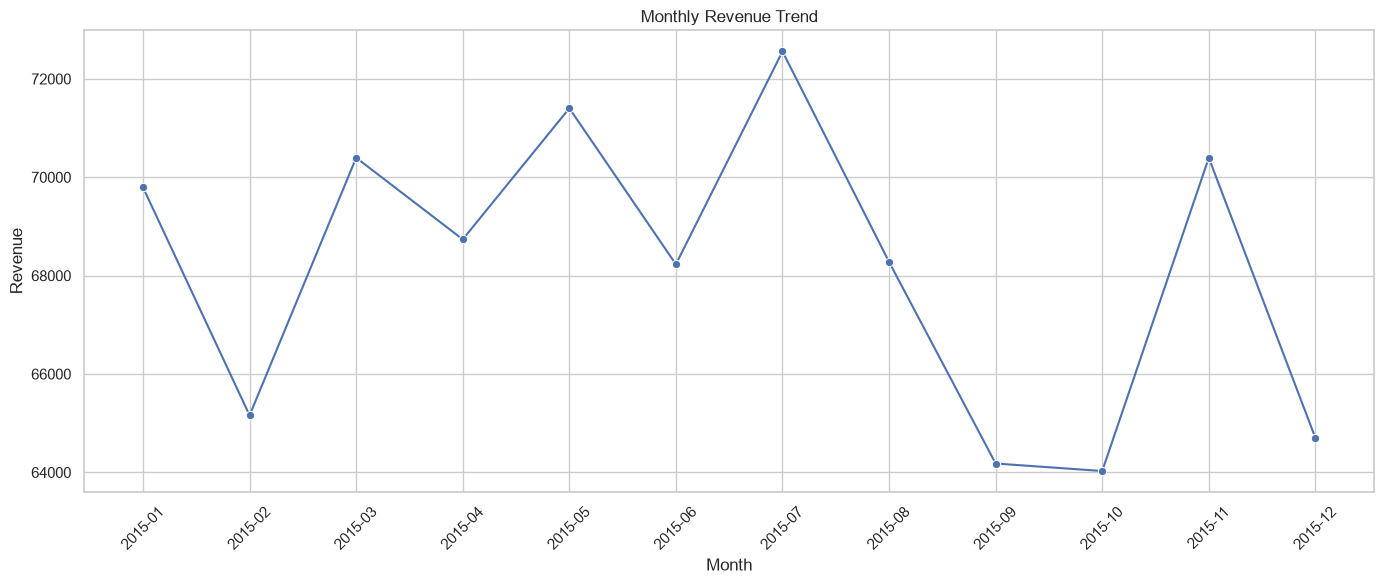

In [78]:
# Monthly Revenue Analysis

# First create a monthly DataFrame:

monthly_revenue = (
    sales_data
    .groupby(
        sales_data["order_date"].dt.to_period("M")
    )["revenue"]
    .sum()
)

# Convert the index:

monthly_revenue.index = (
    monthly_revenue.index.astype(str)
)

# Plot:

plt.figure(figsize=(14, 6))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

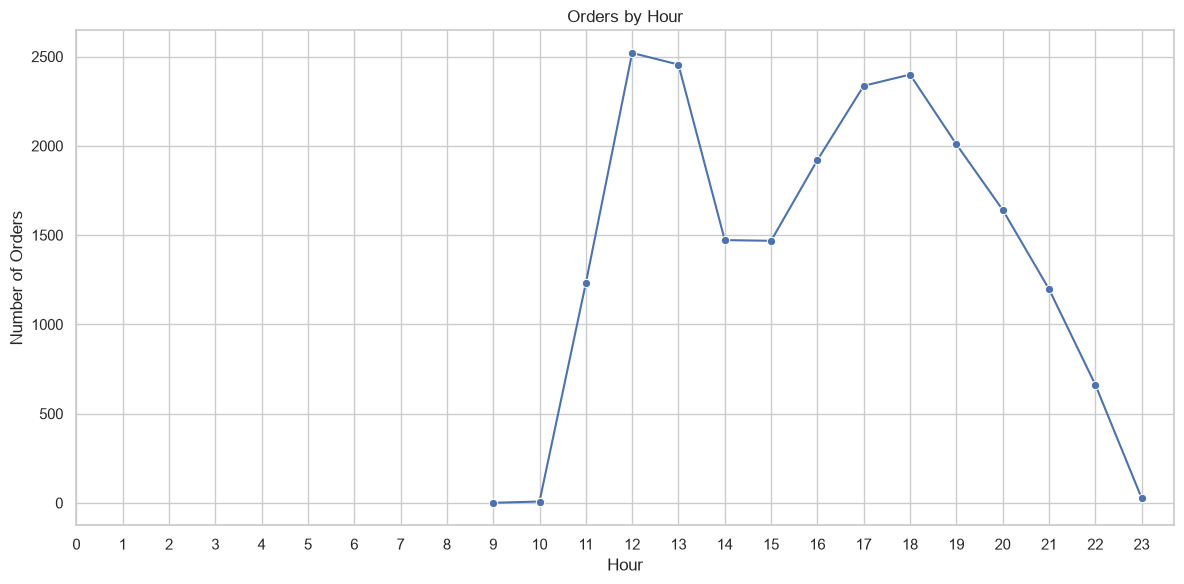

In [79]:
# Orders by Hour
hourly_orders = (
    sales_data
    .groupby("order_hour")["order_id"]
    .nunique()
)

# Plot:

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_orders.index,
    y=hourly_orders.values,
    marker="o"
)

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

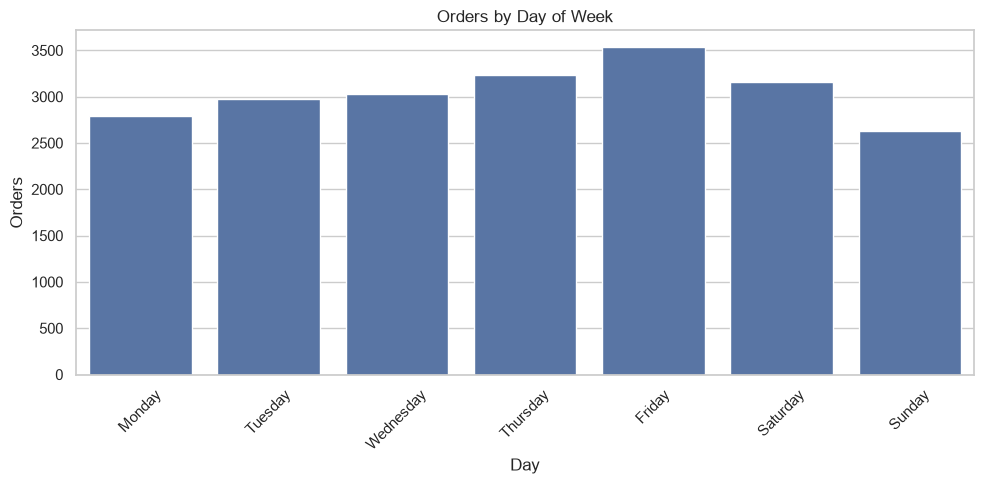

In [80]:
# Orders by Day of Week
day_orders = (
    sales_data
    .groupby("day_name")["order_id"]
    .nunique()
)

# The problem is that alphabetical ordering isn't useful.

# Use:

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_orders = day_orders.reindex(day_order)

# Then:

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_orders.index,
    y=day_orders.values
)

plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [81]:
# Revenue by Category — Percentage

# Using NumPy/Pandas:

category_revenue_pct = (
    category_revenue /
    category_revenue.sum()
) * 100

# Then:

category_revenue_pct

category
Classic    26.905960
Supreme    25.456311
Chicken    23.955138
Veggie     23.682591
Name: revenue, dtype: float64

In [82]:
# Use NumPy

# Since you specifically want NumPy in the project, don't import it and never use it.

# For example, calculate revenue using NumPy:

sales_data["revenue"] = np.multiply(
    sales_data["quantity"],
    sales_data["price"]
)

# You can also calculate revenue contribution:

sales_data["revenue_percentage"] = (
    sales_data["revenue"]
    / sales_data["revenue"].sum()
) * 100

# NumPy is especially useful for numerical calculations and conditional transformations.

In [83]:
# Use np.where()

# For example, classify pizzas based on sales:

pizza_sales = (
    sales_data
    .groupby("name")["quantity"]
    .sum()
    .reset_index()
)

pizza_sales["performance"] = np.where(
    pizza_sales["quantity"] >= pizza_sales["quantity"].median(),
    "High",
    "Low"
)

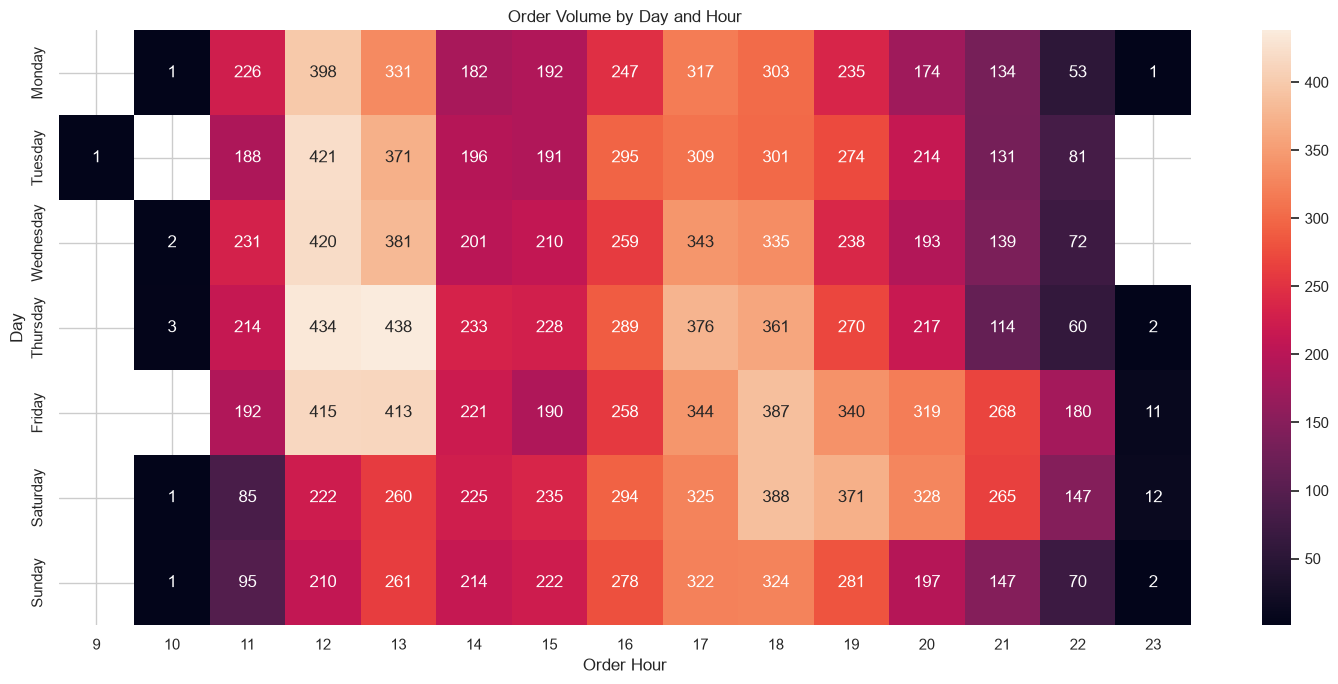

In [84]:
# Use Seaborn for a Heatmap

# This can make your project look much more analytical.

# Create a day/hour matrix:

heatmap_data = (
    sales_data
    .pivot_table(
        index="day_name",
        columns="order_hour",
        values="order_id",
        aggfunc="nunique"
    )
)

# Order the days:

heatmap_data = heatmap_data.reindex(day_order)

# Plot:

plt.figure(figsize=(15, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f"
)

plt.title("Order Volume by Day and Hour")
plt.xlabel("Order Hour")
plt.ylabel("Day")

plt.tight_layout()
plt.show()